# Online Retail (UCI 352) — Production-Grade Unsupervised Segmentation (RFM)

Single-year predecessor to Online Retail II. Column names differ:
`InvoiceNo`, `UnitPrice`, `CustomerID`.

Pipeline: clean → RFM → winsorize + log1p + RobustScaler → survey → k-sweep +
stability → production_score selection → profiles.

**Unsupervised only** — no accuracy / confusion matrix.

In [1]:
from __future__ import annotations

import random
import sys
import warnings
from pathlib import Path

import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from segmentation.metrics import internal_metrics, production_score
from segmentation.preprocess import build_rfm, clean_transactions, prepare_matrix, rfm_quantile_scores
from segmentation.selection import (
    labels_for_config,
    select_best_config,
    survey_algorithms,
    sweep_k,
    top_two_families,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

import pycaret
import sklearn

print("Python:", sys.version.split()[0])
print("pycaret:", pycaret.__version__, "| sklearn:", sklearn.__version__)

Python: 3.13.13
pycaret: 4.0.0a8 | sklearn: 1.9.0


## 1. Data (UCI 352)

In [2]:
retail = fetch_ucirepo(id=352)
raw = retail.data.original.copy() if retail.data.original is not None else retail.data.features.copy()
if "InvoiceNo" not in raw.columns and retail.data.ids is not None:
    raw = pd.concat(
        [retail.data.ids.reset_index(drop=True), retail.data.features.reset_index(drop=True)],
        axis=1,
    )
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
for c in ["InvoiceNo", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID"]:
    assert c in raw.columns, c
display(raw.head(3))

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


## 2. EDA

Missing %:
 InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64
Cancels: 9288
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


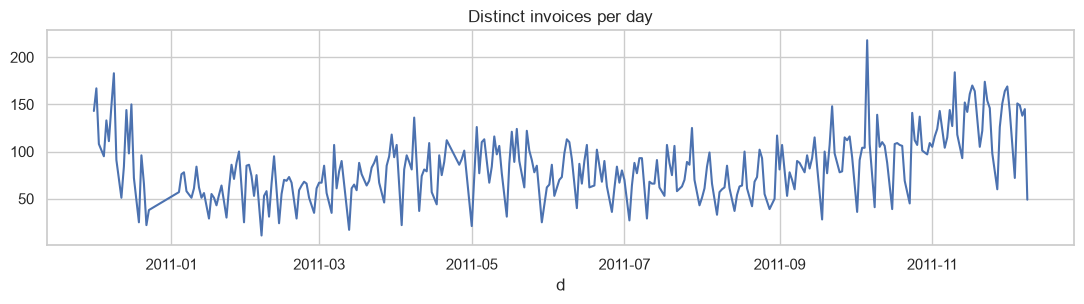

In [3]:
raw = raw.copy()
raw["InvoiceNo"] = raw["InvoiceNo"].astype(str)
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], errors="coerce")
print("Missing %:\n", (100 * raw.isna().mean()).round(2))
print("Cancels:", raw["InvoiceNo"].str.startswith("C").sum())
print("Date range:", raw["InvoiceDate"].min(), "→", raw["InvoiceDate"].max())

daily = (
    raw.dropna(subset=["InvoiceDate"])
    .assign(d=lambda x: x["InvoiceDate"].dt.date)
    .groupby("d")["InvoiceNo"]
    .nunique()
)
fig, ax = plt.subplots(figsize=(11, 3.2))
daily.plot(ax=ax)
ax.set_title("Distinct invoices per day")
plt.tight_layout()
plt.show()

## 3. RFM + production preprocessing

Raw: 541,909 | Cleaned: 397,884 | Customers: 4,338


RFM shape: (4338, 4)


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,307.415000
50%,50.000000,2.000000,674.485000
75%,141.000000,5.000000,1661.740000
max,373.000000,209.000000,280206.020000


Skew:
 Recency       1.246048
Frequency    12.067031
Monetary     19.324953
dtype: float64


,R_score,F_score,M_score,RFM_score
0,1,1,5,7
1,5,5,5,15
2,2,4,4,10
3,4,1,4,9
4,1,1,2,4


Meta: {'scaler': 'robust', 'log_cols': ['Frequency', 'Monetary']}
Winsor bounds:
            lower       upper
Recency      0.0    368.0000
Frequency    1.0     30.0000
Monetary    52.2  19880.9957


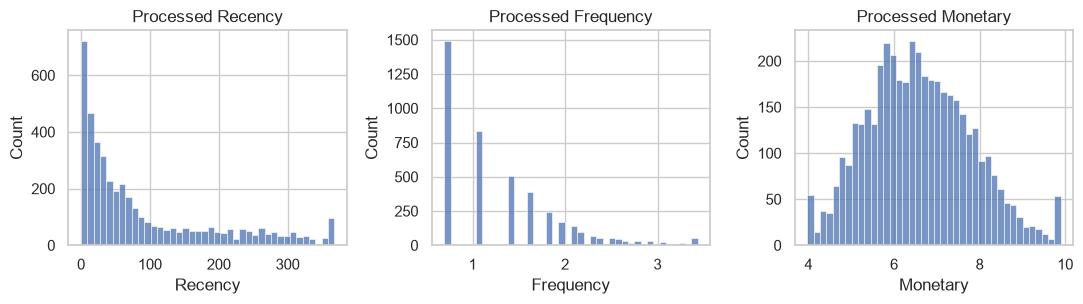

In [4]:
tx = clean_transactions(
    raw,
    invoice_col="InvoiceNo",
    customer_col="CustomerID",
    qty_col="Quantity",
    price_col="UnitPrice",
    date_col="InvoiceDate",
)
print(f"Raw: {len(raw):,} | Cleaned: {len(tx):,} | Customers: {tx['CustomerID'].nunique():,}")

rfm = build_rfm(
    tx,
    customer_col="CustomerID",
    invoice_col="InvoiceNo",
    date_col="InvoiceDate",
)
rfm["CustomerID"] = rfm["CustomerID"].astype(int)
print("RFM shape:", rfm.shape)
display(rfm[["Recency", "Frequency", "Monetary"]].describe())
print("Skew:\n", rfm[["Recency", "Frequency", "Monetary"]].skew())

display(rfm_quantile_scores(rfm)[["R_score", "F_score", "M_score", "RFM_score"]].head())

feat_cols = ["Recency", "Frequency", "Monetary"]
X, work, scaler, meta = prepare_matrix(
    rfm,
    feat_cols,
    winsorize=True,
    log_cols=["Frequency", "Monetary"],
    scaler="robust",
)
print("Meta:", {k: meta[k] for k in ["scaler", "log_cols"]})
print("Winsor bounds:\n", meta["bounds"])

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, c in zip(axes, feat_cols):
    sns.histplot(work[c], bins=40, ax=ax)
    ax.set_title(f"Processed {c}")
plt.tight_layout()
plt.show()

## 4. Survey + deep k-sweep + stability

,model,n_clusters,error,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,production_score
1,minibatch_kmeans,4,,0,0.0,33.218073,12.517289,0.378465,0.861838,4622.509233,0.478194
0,kmeans,4,,0,0.0,32.664822,15.606270,0.372574,0.880210,4658.408273,0.471910
2,hclust,4,,0,0.0,35.569387,14.499769,0.350131,1.115819,3707.525214,0.402091
3,birch,4,,0,0.0,48.847395,0.138313,0.403264,0.790041,3090.304267,0.262770
4,gmm,4,,0,0.0,34.416782,10.580913,0.076191,2.141708,1418.031851,-0.022605


Best 2 families: ['minibatch_kmeans', 'kmeans']

=== Sweep minibatch_kmeans ===


,model,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,stability_ari,inertia,bic,aic,production_score
1,minibatch_kmeans,3,0,0.0,46.634394,22.867681,0.426186,0.798264,4909.574725,0.914100,2036.079802,NaN,NaN,0.649304
2,minibatch_kmeans,4,0,0.0,33.218073,12.517289,0.378465,0.861838,4622.509233,0.757893,1575.213015,NaN,NaN,0.569141
0,minibatch_kmeans,2,0,0.0,59.289995,40.710005,0.398400,0.980065,3613.254343,0.677753,3588.884283,NaN,NaN,0.509722
3,minibatch_kmeans,5,0,0.0,28.354080,14.661134,0.351547,0.989521,4188.363967,0.626117,1332.743751,NaN,NaN,0.503170
4,minibatch_kmeans,6,0,0.0,29.299216,9.658829,0.345742,0.976341,3932.075000,0.527951,1140.912738,NaN,NaN,0.448951
5,minibatch_kmeans,7,0,0.0,23.697556,6.615952,0.329345,0.935605,4004.360567,0.613235,1005.742252,NaN,NaN,0.448216
6,minibatch_kmeans,8,0,0.0,20.539419,5.025357,0.298094,1.014477,3821.969537,0.607644,920.435022,NaN,NaN,0.404512


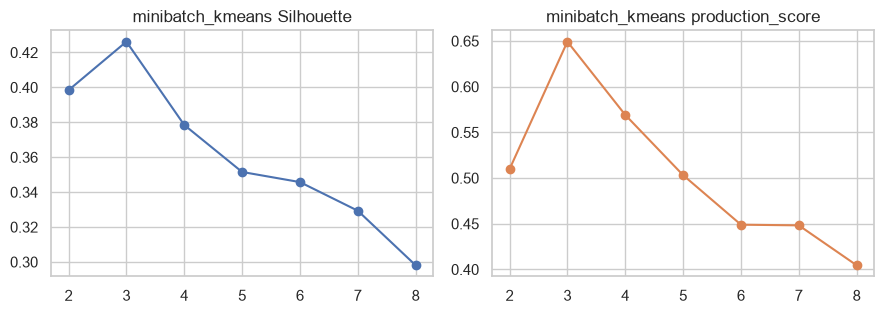


=== Sweep kmeans ===


,model,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,stability_ari,inertia,bic,aic,production_score
1,kmeans,3,0,0.0,45.089903,22.706316,0.425932,0.800800,4916.532586,0.973549,2036.079802,NaN,NaN,0.656190
2,kmeans,4,0,0.0,32.664822,15.606270,0.372574,0.880210,4658.408273,0.943984,1575.213015,NaN,NaN,0.585188
3,kmeans,5,0,0.0,31.327801,13.416321,0.355227,0.949399,4325.525797,0.917489,1332.743751,NaN,NaN,0.549139
0,kmeans,2,0,0.0,50.253573,49.746427,0.393317,0.971438,3703.824973,0.958558,3588.884283,NaN,NaN,0.541744
5,kmeans,7,0,0.0,23.259567,8.298755,0.328879,0.943761,4054.325258,0.957971,1005.742252,NaN,NaN,0.489964
4,kmeans,6,0,0.0,24.435224,8.367911,0.326738,0.989263,4186.998502,0.942037,1140.912738,NaN,NaN,0.486251
6,kmeans,8,0,0.0,19.317658,5.832181,0.298103,1.000243,3853.642057,0.881587,920.435022,NaN,NaN,0.439483


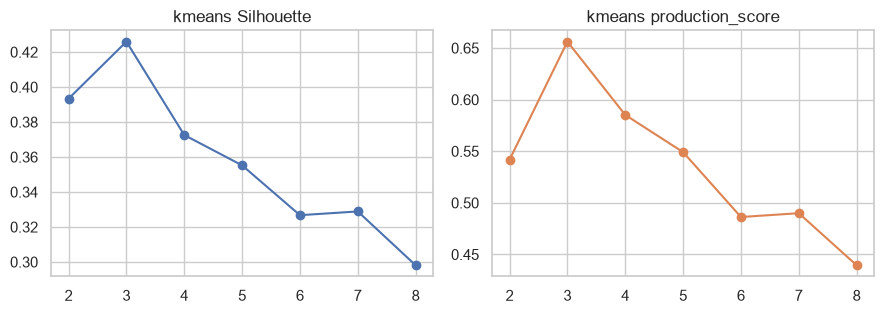

,model,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,stability_ari,inertia,bic,aic,production_score
8,kmeans,3,0,0.0,45.089903,22.706316,0.425932,0.800800,4916.532586,0.973549,2036.079802,NaN,NaN,0.656190
1,minibatch_kmeans,3,0,0.0,46.634394,22.867681,0.426186,0.798264,4909.574725,0.914100,2036.079802,NaN,NaN,0.649304
9,kmeans,4,0,0.0,32.664822,15.606270,0.372574,0.880210,4658.408273,0.943984,1575.213015,NaN,NaN,0.585188
2,minibatch_kmeans,4,0,0.0,33.218073,12.517289,0.378465,0.861838,4622.509233,0.757893,1575.213015,NaN,NaN,0.569141
10,kmeans,5,0,0.0,31.327801,13.416321,0.355227,0.949399,4325.525797,0.917489,1332.743751,NaN,NaN,0.549139
7,kmeans,2,0,0.0,50.253573,49.746427,0.393317,0.971438,3703.824973,0.958558,3588.884283,NaN,NaN,0.541744
0,minibatch_kmeans,2,0,0.0,59.289995,40.710005,0.398400,0.980065,3613.254343,0.677753,3588.884283,NaN,NaN,0.509722
3,minibatch_kmeans,5,0,0.0,28.354080,14.661134,0.351547,0.989521,4188.363967,0.626117,1332.743751,NaN,NaN,0.503170
12,kmeans,7,0,0.0,23.259567,8.298755,0.328879,0.943761,4054.325258,0.957971,1005.742252,NaN,NaN,0.489964
11,kmeans,6,0,0.0,24.435224,8.367911,0.326738,0.989263,4186.998502,0.942037,1140.912738,NaN,NaN,0.486251


Configs:
  kmeans k=3 | Sil=0.4259 | stab=0.974 | prod=0.6562
  minibatch_kmeans k=3 | Sil=0.4262 | stab=0.914 | prod=0.6493


In [5]:
survey = survey_algorithms(
    X,
    models=["kmeans", "minibatch_kmeans", "hclust", "birch", "gmm"],
    n_clusters=4,
    random_state=SEED,
)
display(survey)
best_two = top_two_families(survey)
print("Best 2 families:", best_two)

sweeps = {}
for fam in best_two:
    print(f"\n=== Sweep {fam} ===")
    sw = sweep_k(fam, X, ks=range(2, 9), random_state=SEED, compute_stability=True)
    sweeps[fam] = sw
    display(sw.sort_values("production_score", ascending=False))
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
    axes[0].plot(sw["n_clusters"], sw["silhouette"], "o-")
    axes[0].set_title(f"{fam} Silhouette")
    axes[1].plot(sw["n_clusters"], sw["production_score"], "o-", color="C1")
    axes[1].set_title(f"{fam} production_score")
    plt.tight_layout()
    plt.show()

model_a, k_a, best_row, ranking = select_best_config(sweeps)
display(ranking.head(10))
configs = [(model_a, k_a, best_row)]
other = [m for m in best_two if m != model_a]
if other:
    sw_o = sweeps[other[0]].sort_values("production_score", ascending=False).iloc[0]
    configs.append((other[0], int(sw_o["n_clusters"]), sw_o))

print("Configs:")
for m, k, r in configs:
    print(
        f"  {m} k={k} | Sil={r['silhouette']:.4f} | stab={r.get('stability_ari', np.nan):.3f} | "
        f"prod={r['production_score']:.4f}"
    )

## 5. Final models


### kmeans k=3 {'n_clusters': 3, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': 45.08990318118949, 'min_cluster_pct': 22.706316274781006, 'silhouette': 0.42593237308640686, 'davies_bouldin': 0.8008002807104523, 'calinski_harabasz': 4916.532585971206, 'production_score': 0.6561902637120084}


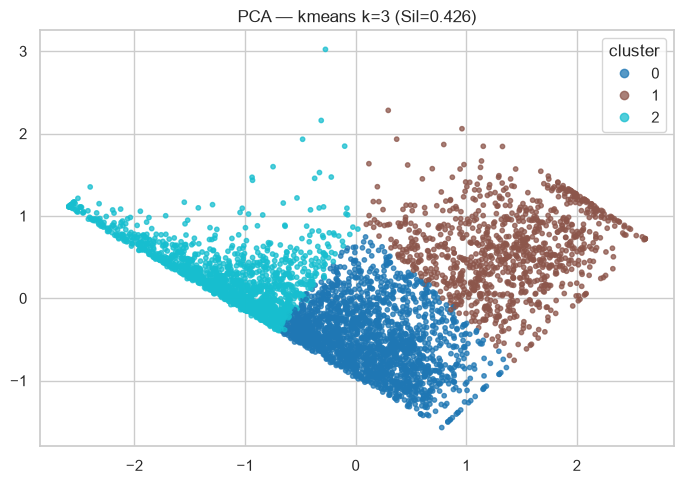

,cluster,n,mean_R,mean_F,mean_M,total_M,median_M,pct_n,pct_M
2,2,1397,29.375805,9.468146,5244.806521,7326994.710,2479.16,32.203781,82.220394
0,0,1956,53.924335,1.993865,565.663427,1106437.663,484.35,45.089903,12.415969
1,1,985,254.386802,1.426396,485.254346,477975.531,298.48,22.706316,5.363637



### minibatch_kmeans k=3 {'n_clusters': 3, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': 46.63439372982941, 'min_cluster_pct': 22.867680958967266, 'silhouette': 0.4261860228684442, 'davies_bouldin': 0.7982643267072972, 'calinski_harabasz': 4909.574724836048, 'production_score': 0.6493041174876687}


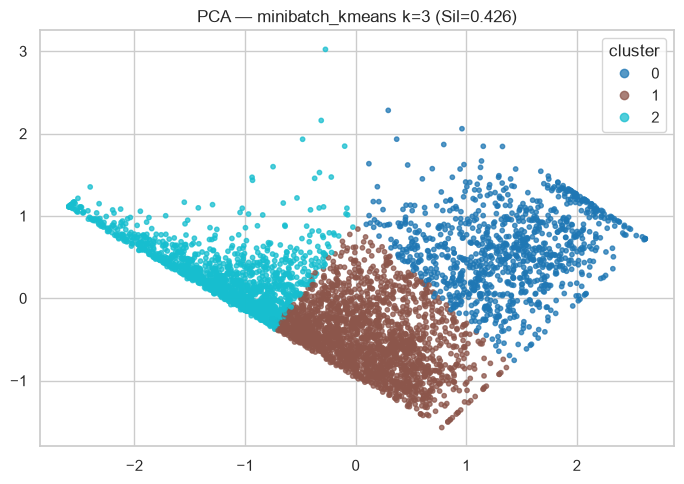

,cluster,n,mean_R,mean_F,mean_M,total_M,median_M,pct_n,pct_M
2,2,1323,28.446712,9.803477,5453.379101,7214820.550,2588.770,30.497925,80.961624
1,1,2023,53.314879,2.049432,601.570412,1216976.943,507.080,46.634394,13.656394
0,0,992,253.622984,1.427419,483.478237,479610.411,298.685,22.867681,5.381982


In [6]:
results = {}
for model_name, k, row in configs:
    labels = labels_for_config(model_name, X, k, random_state=SEED)
    m = internal_metrics(X, labels)
    m["production_score"] = production_score({**m, "stability_ari": row.get("stability_ari", np.nan)})
    print(f"\n### {model_name} k={k}", m)

    Z = PCA(2, random_state=SEED).fit_transform(X)
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=10, alpha=0.75)
    ax.set_title(f"PCA — {model_name} k={k} (Sil={m['silhouette']:.3f})")
    ax.legend(*sc.legend_elements(), title="cluster")
    plt.tight_layout()
    plt.show()

    tmp = rfm.copy()
    tmp["cluster"] = labels
    prof = (
        tmp.groupby("cluster")
        .agg(
            n=("CustomerID", "count"),
            mean_R=("Recency", "mean"),
            mean_F=("Frequency", "mean"),
            mean_M=("Monetary", "mean"),
            total_M=("Monetary", "sum"),
            median_M=("Monetary", "median"),
        )
        .reset_index()
    )
    prof["pct_n"] = 100 * prof["n"] / prof["n"].sum()
    prof["pct_M"] = 100 * prof["total_M"] / prof["total_M"].sum()
    prof = prof.sort_values("mean_M", ascending=False)
    display(prof)

    results[f"{model_name}_k{k}"] = {
        "model": model_name,
        "k": k,
        "labels": labels,
        "metrics": m,
        "profile": prof,
        "row": row,
    }

## 6. Comparison & manager brief

In [7]:
cmp = pd.DataFrame(
    [
        {
            "config": key,
            "model": r["model"],
            "k": r["k"],
            "silhouette": r["metrics"]["silhouette"],
            "davies_bouldin": r["metrics"]["davies_bouldin"],
            "calinski_harabasz": r["metrics"]["calinski_harabasz"],
            "largest_pct": r["metrics"]["largest_cluster_pct"],
            "stability_ari": r["row"].get("stability_ari", np.nan),
            "production_score": r["metrics"]["production_score"],
        }
        for key, r in results.items()
    ]
).sort_values("production_score", ascending=False)
display(cmp)
pref = results[cmp.iloc[0]["config"]]
print("PREFERRED:", cmp.iloc[0]["config"])

prof = pref["profile"]
print("\nMANAGER BRIEF — Online Retail 352 (production pipeline)")
print("=" * 64)
print(
    f"{pref['model']} k={pref['k']} | Sil={pref['metrics']['silhouette']:.3f} | "
    f"DB={pref['metrics']['davies_bouldin']:.3f} | CH={pref['metrics']['calinski_harabasz']:.1f} | "
    f"stab={pref['row'].get('stability_ari', float('nan')):.3f}"
)
print(f"Customers: {len(rfm):,}")
for _, pr in prof.iterrows():
    print(
        f"Segment {int(pr['cluster'])}: n={int(pr['n'])} ({pr['pct_n']:.1f}% cust, {pr['pct_M']:.1f}% rev) | "
        f"R={pr['mean_R']:.0f}d F={pr['mean_F']:.1f} M=£{pr['mean_M']:.0f} (median £{pr['median_M']:.0f})"
    )
print(
    "\nActions: protect high-M/low-R segments; grow mid-frequency; automate low-value lapsed."
)

,config,model,k,silhouette,davies_bouldin,calinski_harabasz,largest_pct,stability_ari,production_score
0,kmeans_k3,kmeans,3,0.425932,0.800800,4916.532586,45.089903,0.973549,0.656190
1,minibatch_kmeans_k3,minibatch_kmeans,3,0.426186,0.798264,4909.574725,46.634394,0.914100,0.649304


PREFERRED: kmeans_k3

MANAGER BRIEF — Online Retail 352 (production pipeline)
kmeans k=3 | Sil=0.426 | DB=0.801 | CH=4916.5 | stab=0.974
Customers: 4,338
Segment 2: n=1397 (32.2% cust, 82.2% rev) | R=29d F=9.5 M=£5245 (median £2479)
Segment 0: n=1956 (45.1% cust, 12.4% rev) | R=54d F=2.0 M=£566 (median £484)
Segment 1: n=985 (22.7% cust, 5.4% rev) | R=254d F=1.4 M=£485 (median £298)

Actions: protect high-M/low-R segments; grow mid-frequency; automate low-value lapsed.
